<a href="https://colab.research.google.com/github/v35001/aoid-team2-ahiyp/blob/main/3%EC%A3%BC%EC%B0%A8_202403081_%EA%B9%80%EC%9D%80%EC%84%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 보건의료 데이터분석 심화 — 3주차 실습
## 결측치 심화 : 진단 · 메커니즘 · 대치 · 민감도 분석

---

**실습 자료**
- `knhanes_like_week3.csv` — 국민건강영양조사 형식을 모사한 합성자료 (3,000명)
- `codebook_week3.csv` — 데이터 사전(코드북)

| 파트 | 내용 | 대응 |
|---|---|---|
| **실습 ①** | 분석 준비 노트북 — 원자료 보존, 데이터 사전 확인, 분석단위, 변수형 점검 | 2주차 이월 |
| **실습 ②** | 결측 진단 → 메커니즘 판단 → 대치 → 민감도 분석 | 3주차 |

---

### 이 노트북 사용법

- `# TODO` 가 붙은 셀이 여러분이 채울 곳입니다. 나머지는 그대로 실행하면 됩니다.
- **앞 셀을 채우지 않으면 뒤 셀이 실행되지 않습니다.** 위에서 아래로 순서대로 진행하십시오.
- 💬 표시가 있는 마크다운 칸에는 직접 문장을 적으십시오. 코드보다 이 칸이 더 중요하게 평가됩니다.

### 중요

> 이 자료에는 MCAR · MAR · MNAR 결측이 **의도적으로** 심어져 있습니다.
> 어떤 변수가 어떤 메커니즘인지는 알려드리지 않습니다. 근거를 만들어 판단하는 것이 과제입니다.

> Colab에서 코드를 고쳐도 자동으로 GitHub에 저장되지 않습니다.
> 작업이 끝나면 **파일 → GitHub에 사본 저장**을 반드시 누르십시오.

---
# 0. 환경 설정

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
np.set_printoptions(suppress=True)

print('pandas', pd.__version__)

pandas 2.2.3


### 자료 불러오기

Colab에서는 아래 셀의 주석을 풀어 파일 2개(`knhanes_like_week3.csv`, `codebook_week3.csv`)를 업로드하십시오.
팀 저장소에 파일을 올려 두었다면 `RAW` 주소로 바로 읽어도 됩니다.

In [40]:
# @title 기본 제목 텍스트
import os

# --- (A) Colab 업로드 ---------------------------------------------
# from google.colab import files
# files.upload()

# --- (B) 팀 저장소 raw 주소에서 읽기 --------------------------------
# RAW = 'https://raw.githubusercontent.com/<팀>/<저장소>/main/data_raw/'
# DATA, BOOK = RAW + 'knhanes_like_week3.csv', RAW + 'codebook_week3.csv'

DATA, BOOK = 'knhanes_like_week3.csv', 'codebook_week3.csv'
print('파일 확인:', os.path.exists(DATA), os.path.exists(BOOK))

파일 확인: True True


---
# 실습 ① — 분석 준비 노트북  *(2주차 이월)*

목표: **정답을 맞히는 것이 아니라, 분석의 시작 과정을 재현 가능하게 만드는 것.**

## 1-1. 원자료 불러오기와 보존

원자료는 **절대 수정하지 않습니다.** 모든 작업은 사본에서만 합니다.

In [41]:
# TODO ① 원자료를 df_raw 로 읽고, 분석용 사본 df 를 만드십시오.
#        힌트: pd.read_csv(...) / .copy()

df_raw = pd.read_csv(DATA)
df = df_raw.copy()

print('행 수:', df_raw.shape[0], '/ 변수 수:', df_raw.shape[1])
df_raw.head()

행 수: 3000 / 변수 수: 19


,id,year,sex,age,edu,income,height,weight,bmi,sbp,dbp,chol,glucose,smk,smk_amt,drink,exercise,htn_med,htn
0,1,2024,1,55,3,3,167.7,50.2,17.86,100,57,146.0,60.0,1,18,1,2,0,0
1,2,2024,1,27,1,3,167.0,NaN,NaN,107,57,132.0,NaN,3,888,2,1,0,0
2,3,2024,1,41,9,1,178.2,70.2,22.11,105,67,155.0,NaN,1,20,3,1,0,0
3,4,2024,2,65,2,1,168.7,65.4,22.99,139,70,169.0,112.0,2,888,2,1,1,1
4,5,2024,1,56,3,2,168.7,76.6,26.94,128,69,185.0,99.0,2,888,2,1,0,0


## 1-2. 분석단위 — 한 행은 무엇인가

행 수와 개인 식별자의 고유값 개수를 비교하면 분석단위를 확인할 수 있습니다.

In [42]:
print('행 수          :', len(df))
print('id 고유값 개수 :', df['id'].nunique())
print('조사연도       :', df['year'].unique())

if len(df) == df['id'].nunique():
    print('\n→ 한 행 = 한 사람 (개인 단위 횡단자료)')
else:
    print('\n→ 한 사람이 여러 행에 존재 — 중복 제거 규칙이 필요하다')

행 수          : 3000
id 고유값 개수 : 3000
조사연도       : [2024]

→ 한 행 = 한 사람 (개인 단위 횡단자료)


💬 **직접 적어보기** — 이 자료의 분석단위와 행 수의 의미를 한 줄로 적으십시오.

> 이 자료의 전체 행 수는 3,000개이고 id의 고유값 개수도 3,000개로 일치하므로 한 행이 한 명의 환자를 나타내는 개인 단위 횡단면 데이터이다.

## 1-3. 데이터 사전(코드북) 확인

변수명만 봐서는 값의 의미를 알 수 없습니다. **결측코드 열을 특히 주의해서 보십시오.**

In [43]:
book = pd.read_csv(BOOK)
book

,변수명,변수설명,변수형,값의 의미,결측코드,비고
0,id,대상자 일련번호,연속형,1–3000,NaN,NaN
1,year,조사연도,범주형,2024,NaN,NaN
2,sex,성별,명목형,"1=남성, 2=여성",9,무응답
3,age,만 나이(세),연속형,19–89,NaN,NaN
4,edu,교육수준,순서형,"1=초졸이하, 2=중졸, 3=고졸, 4=대졸이상",9,무응답
5,income,소득 사분위,순서형,"1=하, 2=중하, 3=중상, 4=상",9,무응답
6,height,신장(cm),연속형,140–195,NaN,NaN
7,weight,체중(kg),연속형,36–135,NaN,빈칸=미측정·응답거부
8,bmi,체질량지수(kg/m²),연속형,14–50,NaN,height·weight에서 산출
9,sbp,수축기혈압(mmHg),연속형,70–220,999,측정 안 함·무응답


## 1-4. 변수형과 기초 분포 점검

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        3000 non-null   int64  
 1   year      3000 non-null   int64  
 2   sex       3000 non-null   int64  
 3   age       3000 non-null   int64  
 4   edu       3000 non-null   int64  
 5   income    3000 non-null   int64  
 6   height    3000 non-null   float64
 7   weight    2543 non-null   float64
 8   bmi       2543 non-null   float64
 9   sbp       3000 non-null   int64  
 10  dbp       3000 non-null   int64  
 11  chol      2635 non-null   float64
 12  glucose   2713 non-null   float64
 13  smk       3000 non-null   int64  
 14  smk_amt   3000 non-null   int64  
 15  drink     3000 non-null   int64  
 16  exercise  3000 non-null   int64  
 17  htn_med   3000 non-null   int64  
 18  htn       3000 non-null   int64  
dtypes: float64(5), int64(14)
memory usage: 445.4 KB


In [45]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
id,3000.0,1500.500000,866.169729,1.0,750.75,1500.50,2250.25,3000.00
year,3000.0,2024.000000,0.000000,2024.0,2024.00,2024.00,2024.00,2024.00
sex,3000.0,1.583333,0.820130,1.0,1.00,2.00,2.00,9.00
age,3000.0,52.105000,15.565284,19.0,41.00,52.00,63.00,89.00
edu,3000.0,2.710000,1.310651,1.0,2.00,3.00,3.00,9.00
income,3000.0,2.968667,1.960518,1.0,2.00,3.00,4.00,9.00
height,3000.0,164.135800,8.980143,139.1,157.20,163.70,170.90,191.30
weight,2543.0,63.967047,9.789714,36.0,57.30,64.00,70.70,96.40
bmi,2543.0,23.976304,3.756113,11.5,21.49,23.89,26.29,37.28
sbp,3000.0,215.281000,277.431231,60.0,108.00,120.00,135.00,999.00


In [46]:
for v in ['sex', 'edu', 'income', 'smk', 'drink', 'exercise', 'htn']:
    print(f'--- {v} ---')
    print(df[v].value_counts(dropna=False).sort_index(), '\n')

--- sex ---
sex
1    1411
2    1566
9      23
Name: count, dtype: int64 

--- edu ---
edu
1     502
2     791
3    1062
4     589
9      56
Name: count, dtype: int64 

--- income ---
income
1    674
2    700
3    702
4    718
9    206
Name: count, dtype: int64 

--- smk ---
smk
1     665
2     535
3    1758
9      42
Name: count, dtype: int64 

--- drink ---
drink
1     889
2    1333
3     778
Name: count, dtype: int64 

--- exercise ---
exercise
1    1732
2    1268
Name: count, dtype: int64 

--- htn ---
htn
0    2437
1     563
Name: count, dtype: int64 



## 1-5. 변수형 오류와 결측 코드 찾기

숫자로 보인다고 모두 연속형이 아닙니다. **9 · 99 · 888 · 999가 실제 값처럼 섞여 있는지** 확인합니다.
아래 스캔 함수는 의심스러운 코드값의 빈도를 세어 줍니다. 최종 판단은 **코드북**을 보고 하십시오.

In [47]:
SUSPECT = [-9, 8, 9, 88, 99, 888, 999, 9999]

def scan_codes(data, suspects=SUSPECT):
    rows = []
    for v in data.columns:
        s = pd.to_numeric(data[v], errors='coerce')
        for code in suspects:
            n = int((s == code).sum())
            if n > 0:
                rows.append({'변수': v, '값': code, 'n': n,
                             '%': round(n / len(data) * 100, 1)})
    return pd.DataFrame(rows)

scan = scan_codes(df)
scan.sort_values(['변수', '값'])

,변수,값,n,%
7,age,88,2,0.1
17,chol,99,5,0.2
14,dbp,88,19,0.6
15,dbp,99,2,0.1
16,dbp,999,333,11.1
8,edu,9,56,1.9
18,glucose,88,56,1.9
19,glucose,99,65,2.2
0,id,8,1,0.0
1,id,9,1,0.0


⚠️ **주의** — 위 표의 값이 모두 결측 코드는 아닙니다.
`edu = 4`, `drink = 3`처럼 **진짜 값**인 경우도 있고, `age = 88`인 사람은 88세이지 무응답이 아닙니다.
반드시 코드북과 대조하십시오.

💬 **직접 적어보기** — 위 표에서 **실제 결측 코드**인 것만 골라 적으십시오.

> dbp = 999, edu = 9, income = 9, sbp = 999, sex = 9, smk = 9, smk_amt = 999

## 1-6. 연구질문과 변수표

2주차에 배운 구조(**대상 · 노출 · 결과 · 시간**)로 작성합니다.

**연구질문**
> 2022년 20대 이상 성인에서 당뇨 증가가 고혈압과 관련이 있는가?

| 구성요소 | 변수명 | 변수형 | 재코딩 | 결측코드 |
|---|---|---|---|---|
| 대상 | `age` | 연속형 | age ≥ 20 | — |
| 노출 | `glucose` | 연속형 | `diabetes` = (glucose ≥ 126) | NaN |
| 결과 | `htn` | 이분형 | 0 / 1 | — |
| 공변량 | `sex` | 명목형 | 1=남성, 2=여성 | 9 |
| 공변량 | `smk` | 명목형 | 1=현재흡연, 2=과거흡연, 3=비흡연 | 9 |
| 공변량 | `bmi` | 연속형 | `obesity` = (bmi ≥ 25) | NaN |
| 시간 | `year` | 범주형 | 2022 선택 | — |

💬 **직접 해보기** — 팀의 연구질문으로 위 표를 다시 작성하십시오.

## 1-7. 분석용 사본 저장

여기까지가 **실습 ①의 산출물**입니다. 원자료는 손대지 않은 상태로 남아 있어야 합니다.

In [50]:
assert df_raw.shape == pd.read_csv(DATA).shape, '원자료가 변경되었습니다!'

df.to_csv('week3_working_copy.csv', index=False, encoding='utf-8-sig')
print('저장 완료: week3_working_copy.csv', df.shape)

저장 완료: week3_working_copy.csv (3000, 19)


---
# 실습 ② — 결측치 진단과 대치  *(3주차)*

## 2-1. 결측 코드 → NaN

**가장 흔한 실수**: 데이터프레임 전체에 대해 9와 99를 한꺼번에 치환하는 것.
그러면 무응답뿐 아니라 진짜 값까지 사라집니다. 반드시 **변수별로** 지정하십시오.
지정표는 코드북(1-3)과 변수표(1-6)에서 나옵니다.

In [51]:
# TODO ② 코드북을 보고 변수별 결측 코드를 지정하십시오.
#        주의: smk_amt 의 888 은 여기에 넣지 마십시오 (2-2에서 따로 처리)

na_map = {
    'sex'    : [9],
    'edu'    : [9],
    'income' : [9],
    'smk'    : [9],
    'sbp'    : [999],
    'dbp'    : [999],
    'smk_amt': [999],
}

for v, codes in na_map.items():
    before = df[v].isna().sum()
    df[v] = df[v].replace(codes, np.nan)
    print(f'{v:9s} 결측 {before:4d} → {df[v].isna().sum():4d}')

sex       결측    0 →   23
edu       결측    0 →   56
income    결측    0 →  206
smk       결측    0 →   42
sbp       결측    0 →  333
dbp       결측    0 →  333
smk_amt   결측    0 →   99


## 2-2. 비해당(논리적 결측) 처리

`smk_amt = 888`은 **결측이 아니라 '해당 없음'**입니다 (비흡연·과거흡연자).
대치 대상에서 빼고, **분석대상자 정의**로 처리합니다.

In [52]:
# TODO ③ 비해당(888)을 어떻게 처리할지 규칙을 정하고 코드로 옮기십시오.
#        여기서는 "비흡연자의 하루 흡연량은 0개비"라는 규칙을 씁니다.

n_na = int((df['smk_amt'] == 888).sum())
df['smk_amt'] = df['smk_amt'].replace(888, 0)                       # 888 → 0
df['smk_amt_applicable'] = (df['smk'] == 1)            # 흡연량 분석 대상 = 현재흡연자

print(f'비해당 888 → 0 으로 정의: {n_na}명')
print(f'흡연량 분석 대상(현재흡연자): {int(df["smk_amt_applicable"].sum())}명')
print('남은 smk_amt 결측(무응답):', int(df['smk_amt'].isna().sum()))

비해당 888 → 0 으로 정의: 2293명
흡연량 분석 대상(현재흡연자): 665명
남은 smk_amt 결측(무응답): 99


## 2-3. 변수별 결측률

**결측률 표는 결과표만큼 중요합니다.** 반드시 출력해서 노트북에 남기십시오.

In [56]:
# TODO ④ 변수별 결측 개수와 비율(%)을 구해 내림차순으로 정렬하십시오.
#        힌트: df.isna().sum() / df.isna().mean()

miss = pd.DataFrame({
    'n_missing': df.isna().sum(),
    'pct'      : df.isna().mean() * 100,
}).sort_values('pct', ascending=False)

miss_tbl = miss[miss['n_missing'] > 0]
miss_tbl

,n_missing,pct
bmi,457,15.233333
weight,457,15.233333
chol,365,12.166667
sbp,333,11.100000
dbp,333,11.100000
glucose,287,9.566667
income,206,6.866667
smk_amt,99,3.300000
edu,56,1.866667
smk,42,1.400000


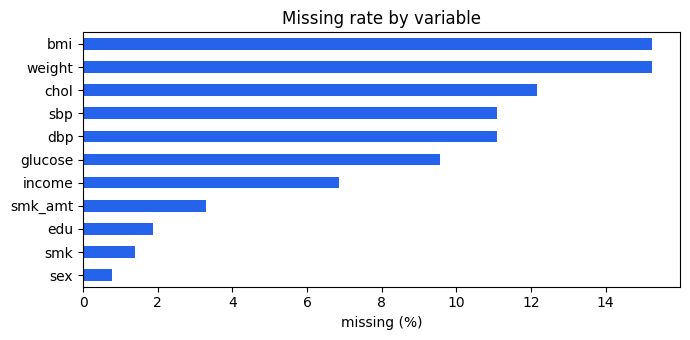

In [57]:
ax = miss_tbl['pct'][::-1].plot(kind='barh', figsize=(7, 3.5), color='#2563EB')
ax.set_xlabel('missing (%)'); ax.set_ylabel(''); ax.set_title('Missing rate by variable')
plt.tight_layout(); plt.show()

## 2-4. 케이스별 결측 개수 — 완전제거하면 얼마나 남는가

In [58]:
# TODO ⑤ 사람마다 몇 개 변수가 비었는지 세고, 완전자료 비율을 구하십시오.
#        힌트: df[VARS].isna().sum(axis=1)

VARS = ['age', 'sex', 'bmi', 'smk', 'income', 'chol', 'glucose', 'htn']

per_case = df[VARS].isna().sum(axis=1)
print(per_case.value_counts().sort_index().rename('명수'))

complete = (per_case == 0).mean()
print(f'\n완전자료 비율 : {complete*100:.1f}%')
print(f'완전제거 시 손실: {(1-complete)*100:.1f}%  ({int((per_case>0).sum())}명)')

0    1846
1     954
2     175
3      24
4       1
Name: 명수, dtype: int64

완전자료 비율 : 61.5%
완전제거 시 손실: 38.5%  (1154명)


## 2-5. 결측 조합 상위 패턴

건너뛰기 규칙이나 수집 과정이 있으면 특정 조합이 몰려서 나타납니다.

In [59]:
pat = df[VARS].isna()
pat_cnt = pat.value_counts().head(6).reset_index(name='n')
pat_cnt['%'] = (pat_cnt['n'] / len(df) * 100).round(1)
pat_cnt

,age,sex,bmi,smk,income,chol,glucose,htn,n,%
0,False,False,False,False,False,False,False,False,1846,61.5
1,False,False,True,False,False,False,False,False,333,11.1
2,False,False,False,False,False,True,False,False,260,8.7
3,False,False,False,False,False,False,True,False,186,6.2
4,False,False,False,False,True,False,False,False,137,4.6
5,False,False,True,False,False,False,True,False,39,1.3


## 2-6. 메커니즘의 근거 만들기

세 단계로 진행합니다.

1. **결측 지시자** 생성
2. 결측군 vs 관측군 **분포 비교** (t검정 · 카이제곱검정)
3. 결측 지시자를 결과로 한 **로지스틱 회귀**

> 어떤 검정도 MAR을 **증명**하지 못합니다. 근거를 만드는 것일 뿐입니다.

In [60]:
from scipy import stats

def compare_missing(data, target, others):
    """target이 결측인 군과 아닌 군에서 other 변수들의 분포를 비교"""
    m = data[target].isna()
    rows = []
    for v in others:
        x0, x1 = data.loc[~m, v].dropna(), data.loc[m, v].dropna()
        if data[v].nunique() > 5:                       # 연속형
            t, p = stats.ttest_ind(x0, x1, equal_var=False)
            rows.append({'변수': v, '관측군': round(x0.mean(), 2),
                         '결측군': round(x1.mean(), 2), '검정': 't', 'p': round(p, 4)})
        else:                                           # 범주형
            tab = pd.crosstab(m, data[v])
            chi2, p, _, _ = stats.chi2_contingency(tab)
            rows.append({'변수': v, '관측군': round(x0.mean(), 2),
                         '결측군': round(x1.mean(), 2), '검정': 'chi2', 'p': round(p, 4)})
    out = pd.DataFrame(rows)
    out['해석'] = np.where(out['p'] < 0.05, '차이 있음 → MCAR 아님', '차이 없음')
    return out

OTHERS = ['age', 'sex', 'edu', 'exercise', 'htn']

for tgt in ['chol', 'sbp', 'glucose', 'income', 'weight']:
    print(f'\n=========== {tgt} 결측 ({df[tgt].isna().mean()*100:.1f}%) ===========')
    print(compare_missing(df, tgt, [v for v in OTHERS if v != tgt]).to_string(index=False))


=========== chol 결측 (12.2%) ===========
      변수   관측군   결측군   검정      p    해석
     age 52.20 51.44    t 0.3968 차이 없음
     sex  1.53  1.52 chi2 0.9597 차이 없음
     edu  2.60  2.56 chi2 0.8784 차이 없음
exercise  1.42  1.44 chi2 0.6327 차이 없음
     htn  0.19  0.17 chi2 0.3909 차이 없음

=========== sbp 결측 (11.1%) ===========
      변수   관측군   결측군   검정      p              해석
     age 50.87 62.01    t 0.0000 차이 있음 → MCAR 아님
     sex  1.53  1.50 chi2 0.3144           차이 없음
     edu  2.60  2.53 chi2 0.0405 차이 있음 → MCAR 아님
exercise  1.43  1.39 chi2 0.1857           차이 없음
     htn  0.18  0.25 chi2 0.0047 차이 있음 → MCAR 아님

=========== glucose 결측 (9.6%) ===========
      변수   관측군   결측군   검정      p              해석
     age 52.18 51.41    t 0.4394           차이 없음
     sex  1.53  1.54 chi2 0.7867           차이 없음
     edu  2.65  2.04 chi2 0.0000 차이 있음 → MCAR 아님
exercise  1.44  1.29 chi2 0.0000 차이 있음 → MCAR 아님
     htn  0.19  0.19 chi2 1.0000           차이 없음

=========== income 결측 (6.9%) ===========
      변수   관

In [61]:
import statsmodels.api as sm

def missing_model(data, target, preds):
    """결측 지시자 ~ 관측변수 로지스틱 회귀"""
    d = data[preds].copy()
    d['_miss'] = data[target].isna().astype(int)
    d = d.dropna()
    res = sm.Logit(d['_miss'], sm.add_constant(d[preds])).fit(disp=0)
    out = pd.DataFrame({'OR': np.exp(res.params).round(3),
                        'p' : res.pvalues.round(4)})
    return out.drop('const')

for tgt in ['chol', 'sbp', 'glucose', 'weight']:
    print(f'\n--- {tgt} 결측을 예측하는 변수 ---')
    print(missing_model(df, tgt, ['age', 'sex', 'edu', 'exercise']))


--- chol 결측을 예측하는 변수 ---
             OR       p
age       0.996  0.2893
sex       0.974  0.8133
edu       0.959  0.4605
exercise  1.080  0.4997

--- sbp 결측을 예측하는 변수 ---
             OR       p
age       1.050  0.0000
sex       0.875  0.2717
edu       0.930  0.2356
exercise  0.802  0.0768

--- glucose 결측을 예측하는 변수 ---
             OR       p
age       0.998  0.5653
sex       1.125  0.3704
edu       0.530  0.0000
exercise  0.502  0.0000

--- weight 결측을 예측하는 변수 ---
             OR       p
age       1.008  0.0217
sex       0.589  0.0000
edu       1.038  0.4728
exercise  0.944  0.5836


### 2-7. 메커니즘 판단표 — 💬 **직접 채우십시오**

| 변수 | 결측률 | 통계적 근거 | 자료수집 과정의 근거 | 판단 | 이유 |
|---|---|---|---|---|---|
| `chol` | 12.2% | t검정, 카이제곱 검정, 로지스틱 회귀 결과 모든 관측변수(연령, 성별 등)와 유의한 관련성이 없음 (p>0.05). | 검사 기기 오류, 담당자 실수 등 개인의 특성이나 수치 자체와 무관하게 무작위로 누락되었을 가능성. | MCAR | 결측 발생이 관측된 변수나 누락된 콜레스테롤 값 자체와 아무런 통계적 연관성이 없으므로 완전히 무작위함. |
| `sbp` | 11.1% | 연령(age), 학력(edu), 고혈압여부(htn)에서 유의한 차이가 있으며, 로지스틱 회귀에서 연령이 유의한 예측 변수(p=0.000)임. | 고령층이나 특정 학력층에서 측정 누락이나 거부가 더 빈번하게 일어났을 수 있음. | MAR | 혈압 값 자체가 아닌, 데이터 내에 관측되어 있는 '연령'이라는 다른 변수에 의해 결측 확률이 설명됨. |
| `glucose` | 9.6% | 학력(edu)과 운동(exercise) 분포에서 매우 유의한 차이(p=0.000)를 보이며, 이 두 변수가 결측을 잘 예측함. | 교육 수준이나 평소 건강 행동(운동 여부)에 따라 공복 유지 및 검사 참여율이 다르게 나타남. | MAR | 누락된 혈당 수치 때문이 아니라, 이미 수집된 학력과 운동 변수에 의해 결측 발생이 체계적으로 설명됨. |
| `income` | 6.9% | 연령(age)과 학력(edu) 분포에서 관측/결측군 간 유의한 차이(p=0.000)가 나타나 MCAR이 기각됨. | 소득은 대표적인 민감 정보로, 소득이 너무 높거나 낮은 특정 계층이 의도적으로 무응답을 선택했을 가능성이 높음. | MNAR | 연령/학력 등으로 일부 설명되나, 본질적으로 누락된 '소득 수치 그 자체'가 무응답의 직접적 원인일 가능성이 높음. |
| `weight` | 15.2% | 성별(sex)과 연령(age)에서 유의한 차이가 나며, 특히 로지스틱 회귀에서 성별(p=0.000)이 강한 결측 예측력을 보임. | 성별에 따라 체중 공개를 꺼리는 경향이 다르고, 실제 체중이 많이 나가는 사람일수록 측정을 거부할 가능성이 큼. | MNAR | 성별 관측값(MAR 특성)으로 결측의 일부가 설명되지만, 궁극적으로 관측되지 않은 '체중' 값 자체가 결측을 유발함. |

**힌트**
- `weight` 결측은 성별로 **일부만** 설명됩니다. 관측변수로 설명되는 부분이 있다고 해서 자동으로 MAR은 아닙니다.
  "체중을 밝히기 꺼리는 사람은 누구인가"를 생각해 보십시오.
- 현실의 결측은 대부분 MAR과 MNAR이 섞여 있습니다. 그래서 **민감도 분석**이 필요합니다.

## 2-8. 세 가지 방법 비교

동일한 분석모형을 **완전제거 · 평균대치 · 다중대치(MICE)** 세 방식으로 돌려 결과를 비교합니다.

**분석모형** — 로지스틱 회귀
`htn ~ obesity + age + male + smk_cur + income + chol + glucose`

In [62]:
# 분석용 변수 준비 (파생변수는 대치 '후' 다시 계산하므로 여기서는 원자료 변수만)
d = df.copy()
d['male']    = (d['sex'] == 1).astype(float)
d.loc[d['sex'].isna(), 'male'] = np.nan
d['smk_cur'] = (d['smk'] == 1).astype(float)
d.loc[d['smk'].isna(), 'smk_cur'] = np.nan

IMP_VARS = ['age', 'male', 'height', 'weight', 'smk_cur', 'income',
            'chol', 'glucose', 'exercise', 'htn']     # 대치모형 (결과변수 htn 포함!)
X_VARS   = ['obesity', 'age', 'male', 'smk_cur', 'income', 'chol', 'glucose']

print('대치모형 변수:', IMP_VARS)
print('결측 현황:')
print(d[IMP_VARS].isna().sum())

대치모형 변수: ['age', 'male', 'height', 'weight', 'smk_cur', 'income', 'chol', 'glucose', 'exercise', 'htn']
결측 현황:
age           0
male         23
height        0
weight      457
smk_cur      42
income      206
chol        365
glucose     287
exercise      0
htn           0
dtype: int64


In [63]:
def fit_logit(data):
    X = sm.add_constant(data[X_VARS].astype(float))
    return sm.Logit(data['htn'].astype(float), X).fit(disp=0)

def summarize(res, label, se=None, coef=None):
    b  = res.params if coef is None else pd.Series(coef, index=res.params.index)
    s  = res.bse    if se   is None else pd.Series(se,   index=res.params.index)
    return pd.DataFrame({
        'method': label,
        'coef'  : b.round(4),
        'se'    : s.round(4),
        'OR'    : np.exp(b).round(3),
        'CI_low': np.exp(b - 1.96 * s).round(3),
        'CI_up' : np.exp(b + 1.96 * s).round(3),
    })

### (a) 완전제거 (listwise deletion)

In [64]:
# TODO ⑥ 완전자료만 남기고(dropna) obesity 를 계산한 뒤 모형을 적합하십시오.

cc = d.dropna(subset=IMP_VARS).copy()                                  # IMP_VARS 에 결측이 하나도 없는 사람만
cc['obesity'] = (cc['weight'] / (cc['height']/100)**2 >= 25).astype(float)                       # BMI = weight / (height/100)**2 ,  >= 25

print(f'원자료 {len(d)}명 → 완전자료 {len(cc)}명 ({len(cc)/len(d)*100:.1f}%)')
res_cc = fit_logit(cc)
out_cc = summarize(res_cc, '① 완전제거')
out_cc

원자료 3000명 → 완전자료 1846명 (61.5%)


,method,coef,se,OR,CI_low,CI_up
const,① 완전제거,-5.8542,0.5909,0.003,0.001,0.009
obesity,① 완전제거,0.3323,0.1394,1.394,1.061,1.832
age,① 완전제거,0.0694,0.0053,1.072,1.061,1.083
male,① 완전제거,-0.2253,0.1425,0.798,0.604,1.055
smk_cur,① 완전제거,0.1360,0.1746,1.146,0.814,1.613
income,① 완전제거,0.0714,0.0599,1.074,0.955,1.208
chol,① 완전제거,0.0014,0.0022,1.001,0.997,1.006
glucose,① 완전제거,-0.0007,0.0042,0.999,0.991,1.008


### (b) 평균 대치 (mean imputation)

**분산이 줄고, 표준오차가 과소추정됩니다.** 비교용으로만 실행합니다.

In [65]:
# TODO ⑦ 결측이 있는 변수를 각 변수의 평균으로 채우십시오.
#        힌트: .fillna(...)

mi = d.copy()
for v in IMP_VARS:
    if mi[v].isna().any():
        mi[v] = mi[v].fillna(mi[v].mean())
mi['obesity'] = (mi['weight'] / (mi['height'] / 100) ** 2 >= 25).astype(float)

res_mean = fit_logit(mi)
out_mean = summarize(res_mean, '② 평균대치')

print('SD 비교 (chol):  원자료 %.2f → 평균대치 후 %.2f'
      % (d['chol'].std(), mi['chol'].std()))
out_mean

SD 비교 (chol):  원자료 30.97 → 평균대치 후 29.03


,method,coef,se,OR,CI_low,CI_up
const,② 평균대치,-6.2867,0.4781,0.002,0.001,0.005
obesity,② 평균대치,0.2794,0.1110,1.322,1.064,1.644
age,② 평균대치,0.0742,0.0041,1.077,1.068,1.086
male,② 평균대치,-0.1512,0.1125,0.860,0.689,1.072
smk_cur,② 평균대치,0.2339,0.1308,1.264,0.978,1.633
income,② 평균대치,0.0287,0.0486,1.029,0.936,1.132
chol,② 평균대치,0.0006,0.0018,1.001,0.997,1.004
glucose,② 평균대치,0.0034,0.0033,1.003,0.997,1.010


### (c) 다중대치 MICE — 대치 → 분석 → 통합

세 단계가 **모두** 있어야 다중대치입니다.

- `sample_posterior=True` — 끄면 매번 같은 값이 나와 다중대치가 되지 않습니다
- `random_state=i` — 반복마다 다르게
- **파생변수 `obesity`(BMI)는 대치 후 다시 계산**합니다 (passive imputation)
- 대치모형에 **결과변수 `htn`을 포함**합니다

In [66]:
# TODO ⑧ m개의 서로 다른 완성 자료를 만드십시오.
#        빠뜨리기 쉬운 것: sample_posterior, random_state, obesity 재계산

from sklearn.experimental import enable_iterative_imputer   # noqa: F401
from sklearn.impute import IterativeImputer

M = 20     # 최대 결측률 약 15% → m ≥ 15. 넉넉하게 20

imps = []
for i in range(M):
    imp = IterativeImputer(max_iter=10, sample_posterior=True, random_state=i)
    filled = pd.DataFrame(imp.fit_transform(d[IMP_VARS]), columns=IMP_VARS)
    filled['obesity'] = (filled['weight'] / (filled['height'] / 100) ** 2 >= 25).astype(float)                  # 파생변수는 대치 후 재계산
    filled['htn'] = d['htn'].values          # 결과변수는 원래 관측값 사용
    imps.append(filled)

print(f'{M}개의 완성 자료 생성 완료 — 각 {imps[0].shape}')
print('자료 1과 자료 2의 대치값이 다른가?',
      not imps[0]['weight'].equals(imps[1]['weight']))

20개의 완성 자료 생성 완료 — 각 (3000, 11)
자료 1과 자료 2의 대치값이 다른가? True


### 통합 — Rubin's rules

슬라이드 15의 공식을 코드로 옮깁니다.

> 총분산 = 대치 내 분산(W) + (1 + 1/m) × 대치 간 분산(B)

In [67]:
# TODO ⑨ Rubin's rules 를 완성하십시오.
#        W = 각 자료 표준오차 제곱의 평균     (대치 내 분산)
#        B = m개 계수의 표본분산 (ddof=1)     (대치 간 분산)

def rubin(imputed_list):
    fits = [fit_logit(x) for x in imputed_list]
    m = len(fits)
    b  = np.mean([f.params.values for f in fits], axis=0)     # 통합 계수
    W  = np.mean([f.bse.values**2 for f in fits], axis=0)
    B  = np.var([f.params.values for f in fits], axis=0, ddof=1)
    se = np.sqrt(W + (1 + 1 / m) * B)                                                  # 총분산의 제곱근
    fmi = ((1 + 1 / m) * B) / (W + (1 + 1 / m) * B)            # 결측정보비율
    return fits[0], b, se, fmi

f0, b_mi, se_mi, fmi = rubin(imps)
out_mice = summarize(f0, '③ 다중대치', se=se_mi, coef=b_mi)
out_mice['FMI'] = np.round(fmi, 3)
out_mice

,method,coef,se,OR,CI_low,CI_up,FMI
const,③ 다중대치,-6.1873,0.4688,0.002,0.001,0.005,0.055
obesity,③ 다중대치,0.2885,0.1166,1.334,1.062,1.677,0.130
age,③ 다중대치,0.0741,0.0041,1.077,1.068,1.086,0.009
male,③ 다중대치,-0.1677,0.1108,0.846,0.681,1.051,0.013
smk_cur,③ 다중대치,0.2300,0.1314,1.259,0.973,1.628,0.025
income,③ 다중대치,0.0228,0.0495,1.023,0.928,1.127,0.126
chol,③ 다중대치,0.0004,0.0018,1.000,0.997,1.004,0.089
glucose,③ 다중대치,0.0029,0.0033,1.003,0.996,1.009,0.079


### (d) 세 방법 비교표 — **이 표가 실습의 핵심 산출물입니다**

In [68]:
compare = pd.concat([out_cc, out_mean, out_mice[out_cc.columns]])
compare = compare.reset_index().rename(columns={'index': 'term'})
pivot = compare.pivot(index='term', columns='method', values=['OR', 'se'])
pivot.round(3)

OR                   se              
method  ① 완전제거 ② 평균대치 ③ 다중대치 ① 완전제거 ② 평균대치 ③ 다중대치
term                                             
age      1.072  1.077  1.077  0.005  0.004  0.004
chol     1.001  1.001  1.000  0.002  0.002  0.002
const    0.003  0.002  0.002  0.591  0.478  0.469
glucose  0.999  1.003  1.003  0.004  0.003  0.003
income   1.074  1.029  1.023  0.060  0.049  0.050
male     0.798  0.860  0.846  0.142  0.112  0.111
obesity  1.394  1.322  1.334  0.139  0.111  0.117
smk_cur  1.146  1.264  1.259  0.175  0.131  0.131

In [69]:
print('표본 수 비교')
print(f'  ① 완전제거 : {len(cc):5d}명  ({len(cc)/len(d)*100:.1f}%)')
print(f'  ② 평균대치 : {len(mi):5d}명  (100.0%)')
print(f'  ③ 다중대치 : {len(d):5d}명  (100.0%)  × {M}개 자료')

print('\n표준오차 비교 (obesity)')
for lab, o in [('① 완전제거', out_cc), ('② 평균대치', out_mean), ('③ 다중대치', out_mice)]:
    print(f'  {lab}: se = {o.loc["obesity", "se"]:.4f}   OR = {o.loc["obesity", "OR"]:.3f}')

표본 수 비교
  ① 완전제거 :  1846명  (61.5%)
  ② 평균대치 :  3000명  (100.0%)
  ③ 다중대치 :  3000명  (100.0%)  × 20개 자료

표준오차 비교 (obesity)
  ① 완전제거: se = 0.1394   OR = 1.394
  ② 평균대치: se = 0.1110   OR = 1.322
  ③ 다중대치: se = 0.1166   OR = 1.334


💬 **직접 해석하기 (3줄)**

1. 세 방법의 표본 수는 어떻게 달랐는가?
2. 평균대치의 표준오차는 다중대치와 비교해 어떠한가? 왜 그런가?
3. 오즈비의 방향과 크기는 방법에 따라 달라졌는가? 결론이 바뀔 정도인가?

> 1. 완전제거 방법은 결측치가 없는 1,846명(61.5%)만을 분석 대상으로 삼은 반면, 평균대치와 다중대치 방법은 누락된 표본 없이 원자료와 동일한 전체 3,000명을 분석에 활용(다중대치는 20개의 완성 자료 생성)했다.
2. 비만(obesity) 변수의 평균대치 표준오차(0.1110)는 다중대치 표준오차(0.1166)보다 작게 나타났는데, 이는 결측치를 단일한 평균값으로 일괄 대치하면서 변수의 분산이 인위적으로 줄어들어 표준오차가 과소추정되었기 때문이다.
3. 비만에 대한 오즈비는 완전제거 1.394, 평균대치 1.322, 다중대치 1.334로 대치 방법에 따라 그 크기가 약간 달라졌으나, 세 방법 모두 방향성(1보다 큰 양의 상관관계)을 동일하게 유지하고 있어 연구의 결론이 바뀔 정도의 차이는 없었다.

### (e) 대치 품질 확인 — 관측값 vs 대치값 분포

대치값이 관측값과 전혀 다른 범위에 있으면 대치모형이 잘못된 것입니다.

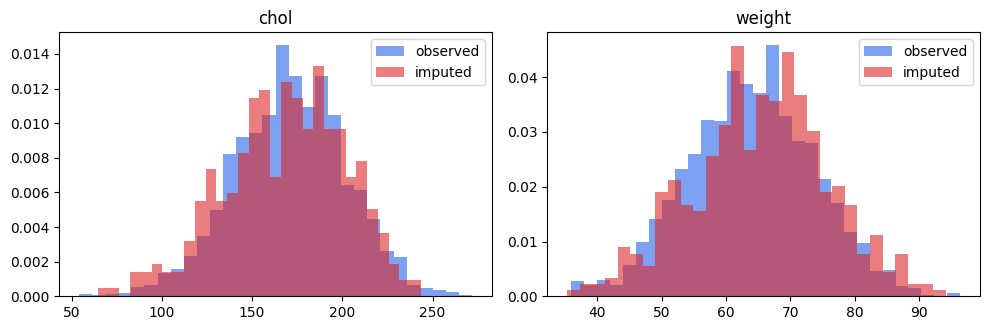

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, v in zip(axes, ['chol', 'weight']):
    obs = d[v].dropna()
    imp_vals = imps[0].loc[d[v].isna(), v]
    ax.hist(obs, bins=30, alpha=0.6, density=True, label='observed', color='#2563EB')
    ax.hist(imp_vals, bins=30, alpha=0.6, density=True, label='imputed', color='#DC2626')
    ax.set_title(v); ax.legend()
plt.tight_layout(); plt.show()

## 2-9. δ 민감도 분석 — MNAR을 다루는 방법

MNAR은 검정으로 확인할 수 없습니다. 대신 **가정을 바꿔가며 결과가 얼마나 흔들리는지** 봅니다.

가정: *"체중을 밝히지 않은 사람은 실제로는 더 무거웠을 것이다."*
→ MAR 대치값에만 δ × SD 만큼 더한 뒤, **`obesity`를 다시 계산해서** 재분석합니다.

δ = 0은 MAR 가정(표준 다중대치)이고, δ > 0은 MNAR 가정을 점점 강하게 넣는 것입니다.

In [71]:
# TODO ⑩ 대치된 체중에만 delta * SD 를 더하고, obesity 를 다시 계산하십시오.

sd_w = d['weight'].std()
miss_w = d['weight'].isna().values
print(f'weight 결측 {miss_w.sum()}명 ({miss_w.mean()*100:.1f}%) · SD = {sd_w:.1f} kg')

rows = []
for delta in [0.0, 0.25, 0.5, 0.75, 1.0]:
    adj = []
    for x in imps:
        xx = x.copy()
        xx.loc[miss_w, 'weight'] = xx.loc[miss_w, 'weight'] + (delta * sd_w)          # 대치값에만 delta * sd_w 가산
        xx['obesity'] = (xx['weight'] / (xx['height'] / 100) ** 2 >= 25).astype(float)                     # δ 적용 후 다시 계산
        adj.append(xx)
    f0d, bd, sed, _ = rubin(adj)
    i = list(f0d.params.index).index('obesity')
    rows.append({'delta (SD)': delta,
                 '비만율(%)': round(float(np.mean([x['obesity'].mean() for x in adj]) * 100), 1),
                 'OR'    : round(float(np.exp(bd[i])), 3),
                 'CI_low': round(float(np.exp(bd[i] - 1.96 * sed[i])), 3),
                 'CI_up' : round(float(np.exp(bd[i] + 1.96 * sed[i])), 3)})

sens = pd.DataFrame(rows)
sens

weight 결측 457명 (15.2%) · SD = 9.8 kg


,delta (SD),비만율(%),OR,CI_low,CI_up
0,0.00,37.0,1.334,1.062,1.677
1,0.25,38.3,1.333,1.066,1.666
2,0.50,39.6,1.322,1.056,1.656
3,0.75,40.9,1.317,1.056,1.642
4,1.00,42.1,1.312,1.048,1.643


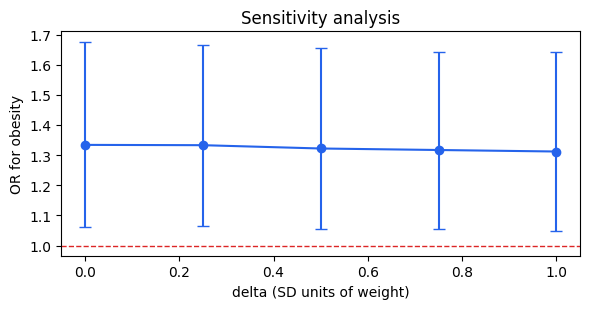

In [72]:
plt.figure(figsize=(6, 3.2))
plt.errorbar(sens['delta (SD)'], sens['OR'],
             yerr=[sens['OR'] - sens['CI_low'], sens['CI_up'] - sens['OR']],
             fmt='o-', capsize=4, color='#2563EB')
plt.axhline(1.0, color='#DC2626', ls='--', lw=1)
plt.xlabel('delta (SD units of weight)'); plt.ylabel('OR for obesity')
plt.title('Sensitivity analysis'); plt.tight_layout(); plt.show()

💬 **직접 해석하기**

> δ를 0에서 +1SD까지 움직였을 때 비만 유병률과 오즈비, 신뢰구간은 어떻게 변했는가?
> 결론(관련성의 방향과 유의성)이 뒤집혔는가?
> **결론이 δ에 따라 뒤집힌다면, 그 결론은 자료가 아니라 가정에서 나온 것입니다.**

> 1. δ 값이 0에서 1.0(SD)으로 증가함에 따라 비만 유병률은 37.0%에서 42.1%로 꾸준히 증가했습니다. 반면 오즈비(OR)는 1.334에서 1.312로 소폭 감소했고, 95% 신뢰구간 역시 [1.062, 1.677]에서 [1.048, 1.643]으로 전체적으로 약간 낮아지는 경향을 보였다.
2. 결론은 뒤집히지 않았다. 체중 결측자가 실제로는 훨씬 더 무거웠을 것이라는 극단적인 비무작위 결측(MNAR) 가정(δ=1.0)을 적용했음에도 불구하고, 신뢰구간의 하한값이 모두 1보다 크기 때문에(최소 1.048) 통계적으로 유의미한 양(+)의 관련성이 그대로 유지되었다.

## 2-10. 분석자료 저장과 보고 문장

In [73]:
analytic = imps[0].copy()      # 실제 보고는 m개 통합 결과를 쓰되, 기술통계용으로 1개 저장
analytic.to_csv('week3_analytic.csv', index=False, encoding='utf-8-sig')

miss_tbl.to_csv('week3_missing_table.csv', encoding='utf-8-sig')
compare.to_csv('week3_method_comparison.csv', index=False, encoding='utf-8-sig')
sens.to_csv('week3_sensitivity.csv', index=False, encoding='utf-8-sig')

print('저장 완료:')
for f in ['week3_analytic.csv', 'week3_missing_table.csv',
          'week3_method_comparison.csv', 'week3_sensitivity.csv']:
    print('  -', f)

저장 완료:
  - week3_analytic.csv
  - week3_missing_table.csv
  - week3_method_comparison.csv
  - week3_sensitivity.csv


### Methods 문장 (여러분의 숫자로 바꿔 쓰십시오)

> "본 연구에서는 체중(weight) 변수의 결측치가 총 457명(15.2%) 발생함에 따라, 해당 결측이 비무작위 결측(MNAR, Missing Not At Random)일 가능성을 고려하여 민감도 분석(Sensitivity analysis)을 수행하였다. 체중을 누락한 대상자가 실제로는 체중이 더 많이 나갈 수 있다는 가정하에, 델타(δ) 기반 조정 방법을 사용하였다. 다중대치된 결측값에 체중의 표준편차(SD = 9.8 kg)를 기준으로 δ값을 0에서 1 SD까지 점진적으로 가산하며 분석 결과의 건건성(Robustness)을 평가하였다."

---
# 제출 체크리스트

**실습 ① (2주차 이월)**
- [ ] `df_raw` 보존 확인 (assert 셀 통과)
- [ ] 데이터 사전 기반 변수 5개 확인
- [ ] 분석단위와 행 수 설명 1줄
- [ ] 변수형 오류 / 결측 코드 목록
- [ ] 연구질문 1개 + 변수표 1개
- [ ] 분석용 사본 CSV 생성

**실습 ② (3주차)**
- [ ] 결측 코드 → NaN (변수별 지정)
- [ ] 비해당(888) 처리 규칙 명시
- [ ] 변수별 결측률 표 + 케이스별 결측 개수
- [ ] 메커니즘 판단표 (근거 포함)
- [ ] 세 방법 비교표 (계수 · 표준오차)
- [ ] δ 민감도 분석 + 해석 3줄

**저장**
- [ ] Colab: **파일 → GitHub에 사본 저장** (팀 저장소 / branch = main / 커밋 메시지 한 줄)
- [ ] 생성된 CSV는 `data_processed/`에 업로드 (`data_raw/`는 .gitignore)
- [ ] LMS에 노트북 링크 제출